In [2]:
import scipy.io as sio
import numpy as np
import matplotlib.pyplot as plt
import pywt

In [3]:
data = sio.loadmat(r'F:\NeuTech\CWRU\ball.mat')

In [4]:
Ball_CW = data['Ball_CW']

In [5]:
x = Ball_CW[0,0][0,0].astype(float).ravel()

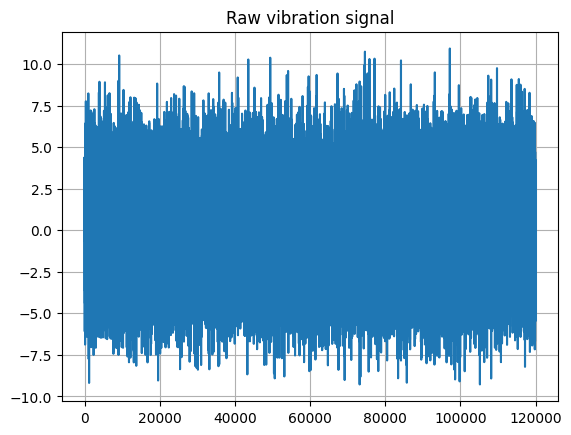

In [6]:
plt.plot(x); plt.title("Raw vibration signal"); plt.grid(True); plt.show()

In [7]:
x_norm = (x - x.mean()) / x.std()

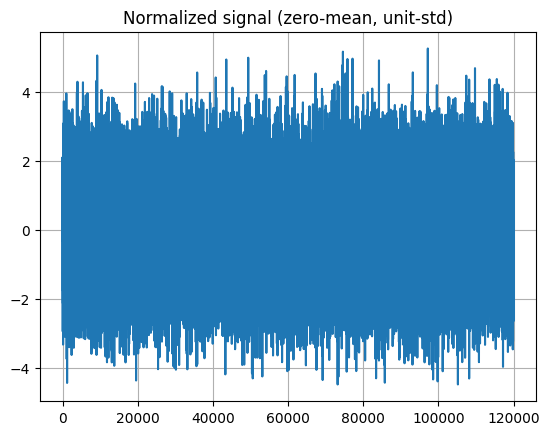

In [8]:
plt.plot(x_norm); plt.title("Normalized signal (zero-mean, unit-std)"); plt.grid(True); plt.show()

In [9]:
x_clean = np.clip(x_norm, -3, 3)

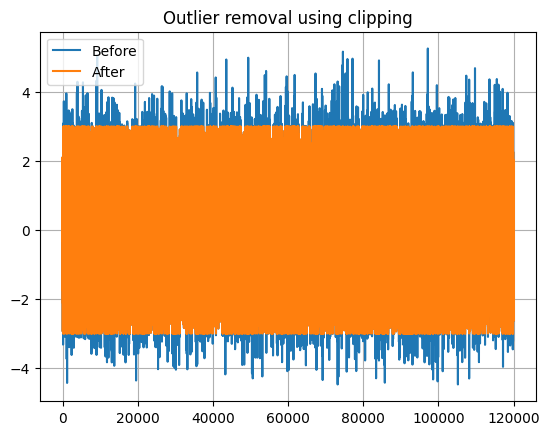

In [10]:
plt.plot(x_norm); plt.plot(x_clean); plt.legend(["Before","After"]); plt.title("Outlier removal using clipping"); plt.grid(True); plt.show()

In [11]:
scales = np.arange(1, 128)
cfs, freqs = pywt.cwt(x_clean, scales, 'morl')

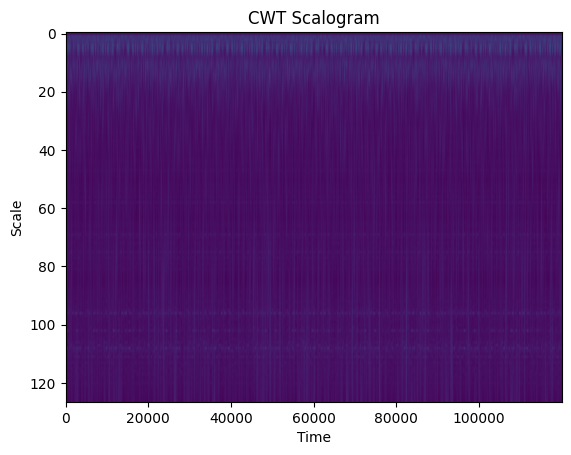

In [12]:
plt.imshow(np.abs(cfs), aspect='auto'); plt.title("CWT Scalogram"); plt.xlabel("Time"); plt.ylabel("Scale"); plt.show()

In [13]:
x = Ball_CW[0,0][0,0].astype(float).ravel()

In [14]:
from scipy.signal import detrend
x_det = detrend(x)

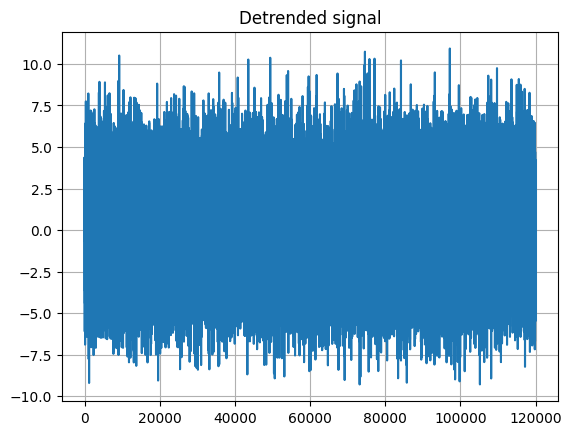

In [15]:
plt.plot(x_det); plt.title("Detrended signal"); plt.grid(True); plt.show()

In [16]:
x_smooth = np.convolve(x_det, np.ones(5)/5, mode='same')

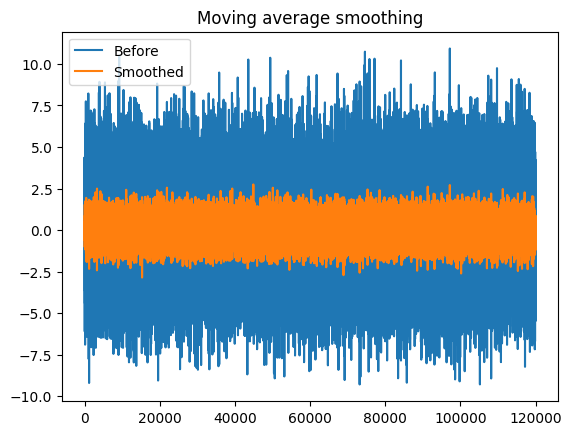

In [17]:
plt.plot(x_det); plt.plot(x_smooth); plt.legend(["Before","Smoothed"]); plt.title("Moving average smoothing"); plt.show()

In [18]:
x_minmax = (x_smooth - x_smooth.min()) / (x_smooth.max() - x_smooth.min())

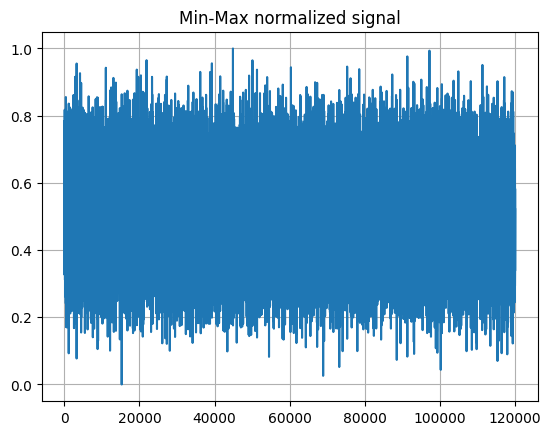

In [19]:
plt.plot(x_minmax); plt.title("Min-Max normalized signal"); plt.grid(True); plt.show()

In [20]:
from scipy.signal import hilbert
env = np.abs(hilbert(x_smooth))

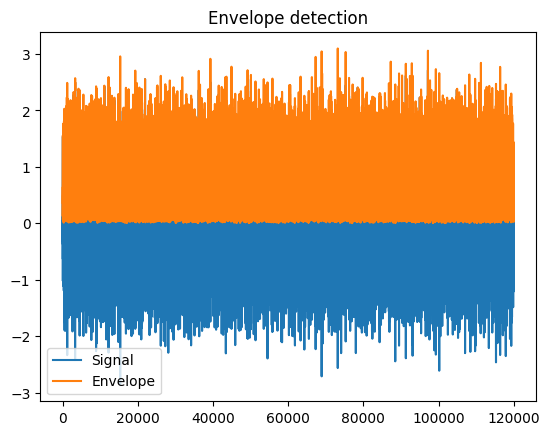

In [21]:
plt.plot(x_smooth); plt.plot(env); plt.legend(["Signal","Envelope"]); plt.title("Envelope detection"); plt.show()

In [22]:
X = np.fft.rfft(x_smooth)
f = np.fft.rfftfreq(len(x_smooth), d=1)

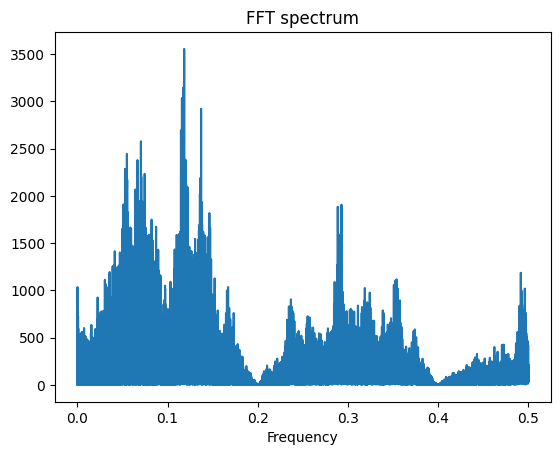

In [23]:
plt.plot(f, np.abs(X)); plt.title("FFT spectrum"); plt.xlabel("Frequency"); plt.show()